## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import shap

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


## Load & Merge Data

In [2]:
# ======================================================
# Paths
# ======================================================
BASE_PATH = "."

path_level_rain_pressure = os.path.join(
    BASE_PATH, "data/nivel-pocos_chuva_pressao_tratados.csv"
)
path_wells_func = os.path.join(
    BASE_PATH, "data/funcionamento_pocos_30min.csv"
)
path_earth_tide = os.path.join(
    BASE_PATH, "data/earth_tide.csv"
)

# ======================================================
# Load data
# ======================================================
level_rain_pressure = pd.read_csv(path_level_rain_pressure)
wells_func = pd.read_csv(path_wells_func)
earth_tide = pd.read_csv(path_earth_tide)

# ======================================================
# Standardize datetime column
# ======================================================
if "datetime" in earth_tide.columns:
    earth_tide = earth_tide.rename(columns={"datetime": "date_time"})

for df_ in [level_rain_pressure, wells_func, earth_tide]:
    if "date_time" not in df_.columns:
        raise ValueError("Dataset missing 'date_time' column.")

# ======================================================
# Rename variables (standard naming)
# ======================================================
rename_map = {
    "pressao_mH2O_final": "baro_ig_mH2O",
    "gmu_level_mH2O_compensado": "gmu_gwl_mH2O",
    "chuva_mm_30min": "rain_mm_30min",
    "status_IMECC": "status_IME",
    "status_ZOOLOGIA": "status_IBZ",
}

level_rain_pressure = level_rain_pressure.rename(columns=rename_map)
wells_func = wells_func.rename(columns=rename_map)

# ======================================================
# Clean pumping status (binary)
# ======================================================
wells_func = wells_func.dropna()
pumping_cols = wells_func.columns.difference(["date_time"])
wells_func[pumping_cols] = wells_func[pumping_cols].astype(int)

# ======================================================
# Merge datasets
# ======================================================
data = (
    level_rain_pressure
    .merge(wells_func, on="date_time", how="outer")
    .merge(earth_tide, on="date_time", how="outer")
)

data["date_time"] = pd.to_datetime(data["date_time"])
data = data.sort_values("date_time").reset_index(drop=True)

print("Merged shape:", data.shape)

Merged shape: (70080, 8)


## Filter Period

In [3]:
# ======================================================
# Filter analysis period
# ======================================================
START_DATE = "2024-12-08 23:00:00"
END_DATE   = "2025-08-14 16:00:00"

data = data[
    (data["date_time"] >= START_DATE) &
    (data["date_time"] <= END_DATE)
].copy()

print(f"Using period {START_DATE} → {END_DATE}")
print("Shape after filtering:", data.shape)

# ======================================================
# Set time index
# ======================================================
df = data.set_index("date_time").copy()

# ======================================================
# select only gwl
df = df[["gmu_gwl_mH2O", "baro_ig_mH2O", "earth_tide_nm/s2"]].copy()

Using period 2024-12-08 23:00:00 → 2025-08-14 16:00:00
Shape after filtering: (11939, 8)


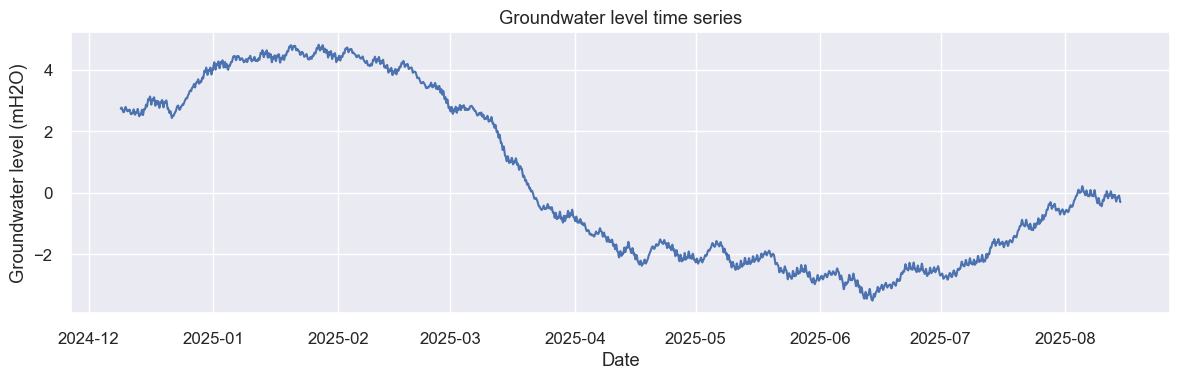

In [4]:
# garantir que o índice é datetime
df.index = pd.to_datetime(df.index)

plt.figure(figsize=(12, 4))
plt.plot(df.index, df["gmu_gwl_mH2O"])
plt.xlabel("Date")
plt.ylabel("Groundwater level (mH2O)")
plt.title("Groundwater level time series")
plt.grid(True)
plt.tight_layout()
plt.show()

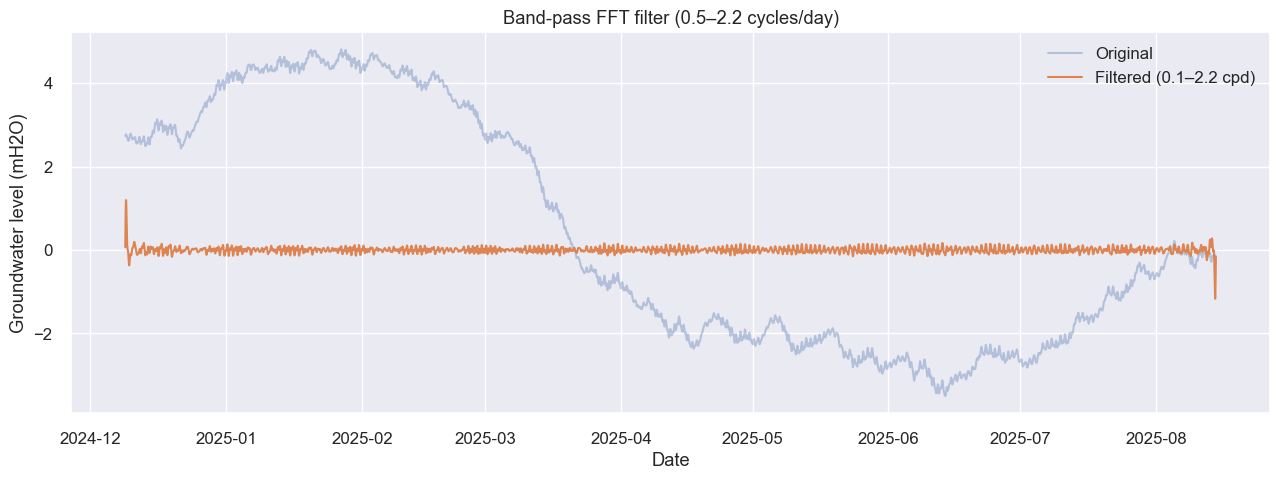

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# Configurações
# ============================
col = "gmu_gwl_mH2O"
dt_days = 0.5 / 24  # 30 minutos em dias

fmin = 0.5  # ciclos por dia
fmax = 2.2  # ciclos por dia

# ============================
# Série temporal
# ============================
series = df[col].values
time = df.index

n = len(series)

# ============================
# FFT
# ============================
fft_vals = np.fft.fft(series)
freqs = np.fft.fftfreq(n, d=dt_days)  # cpd

# ============================
# Filtro passa-banda
# ============================
band_mask = (np.abs(freqs) >= fmin) & (np.abs(freqs) <= fmax)

fft_filtered = np.zeros_like(fft_vals)
fft_filtered[band_mask] = fft_vals[band_mask]

# ============================
# IFFT
# ============================
filtered_series = np.real(np.fft.ifft(fft_filtered))

# ============================
# Plot
# ============================
plt.figure(figsize=(13, 5))
plt.plot(time, series, alpha=0.35, label="Original")
plt.plot(time, filtered_series, label="Filtered (0.1–2.2 cpd)")
plt.xlabel("Date")
plt.ylabel("Groundwater level (mH2O)")
plt.title("Band-pass FFT filter (0.5–2.2 cycles/day)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
import plotly.graph_objects as go

fig = go.Figure()

# Série original
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["gmu_gwl_mH2O"],
        mode="lines",
        name="Original",
        opacity=0.4
    )
)

# Série filtrada
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=filtered_series,
        mode="lines",
        name="Filtered (0.5–2.2 cpd)"
    )
)

fig.update_layout(
    title="Groundwater level – band-pass filtered (0.5–2.2 cpd)",
    xaxis_title="Date",
    yaxis_title="Groundwater level (mH2O)",
    hovermode="x unified",
    template="plotly_white",
    height=450
)

fig.show()


In [7]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# ============================
# Configurações
# ============================
col = "gmu_gwl_mH2O"
samples_per_day = 48       # 30 min
dt_days = 1 / samples_per_day
edge_days = 5
edge_samples = edge_days * samples_per_day
n_peaks = 5

# ============================
# Séries temporais
# ============================
original_series = pd.Series(df[col].values, index=df.index)
filtered_series_pd = pd.Series(filtered_series, index=df.index)

# remover 2 primeiros e 2 últimos dias
original_valid = original_series.iloc[edge_samples:-edge_samples]
filtered_valid = filtered_series_pd.iloc[edge_samples:-edge_samples]

# ============================
# Função: picos dominantes
# ============================
def dominant_frequencies(series, dt_days, n_peaks):
    x = series.values
    n = len(x)

    fft_vals = np.fft.fft(x)
    freqs = np.fft.fftfreq(n, d=dt_days)
    power = np.abs(fft_vals) ** 2

    # apenas frequências positivas
    mask = freqs > 0
    freqs_pos = freqs[mask]
    power_pos = power[mask]

    peaks, _ = find_peaks(power_pos)

    # ordenar por potência (decrescente)
    peaks_sorted = peaks[np.argsort(power_pos[peaks])[::-1]]

    return freqs_pos[peaks_sorted[:n_peaks]]

# ============================
# Estatísticas + frequências
# ============================
data = []

for label, series in {
    "Original": original_valid,
    "Filtered (0.5–2.2 cpd)": filtered_valid
}.items():

    freqs_dom = dominant_frequencies(series, dt_days, n_peaks)

    row = {
        "mean": series.mean(),
        "std": series.std(),
        "amplitude": series.max() - series.min()
    }

    # adicionar picos como colunas
    for i, f in enumerate(freqs_dom, start=1):
        row[f"peak_{i}_cpd"] = f

    data.append(pd.Series(row, name=label))

# ============================
# DataFrame final
# ============================
results_df = pd.DataFrame(data)

results_df


,mean,std,amplitude,peak_1_cpd,peak_2_cpd,peak_3_cpd,peak_4_cpd,peak_5_cpd
Original,0.335939,2.816443,8.310350,0.016755,0.037700,0.046077,0.058644,0.142421
Filtered (0.5–2.2 cpd),0.000097,0.057590,0.340052,1.001134,1.931059,2.002269,0.929924,0.712104


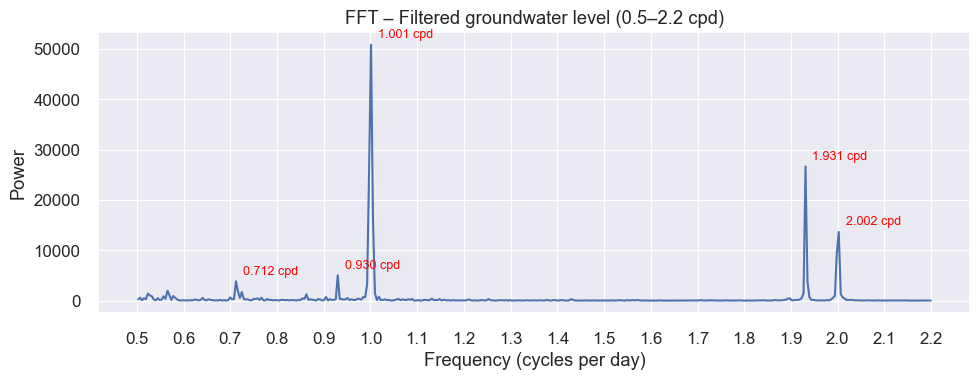

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ============================
# Configurações
# ============================
samples_per_day = 48       # 30 min
dt_days = 1 / samples_per_day
fmin = 0.5
fmax = 2.2

# ============================
# Série filtrada válida (sem bordas)
# ============================
filtered_valid = filtered_series_pd.iloc[edge_samples:-edge_samples]

x = filtered_valid.values
n = len(x)

# ============================
# FFT
# ============================
fft_vals = np.fft.fft(x)
freqs = np.fft.fftfreq(n, d=dt_days)
power = np.abs(fft_vals) ** 2

mask = (freqs >= fmin) & (freqs <= fmax)
freqs_plot = freqs[mask]
power_plot = power[mask]

# ============================
# Plot
# ============================
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(freqs_plot, power_plot)
ax.set_xlabel("Frequency (cycles per day)")
ax.set_ylabel("Power")
ax.set_title("FFT – Filtered groundwater level (0.5–2.2 cpd)")

ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.grid(True, which="major", axis="both", linewidth=0.8)

# ============================
# Picos identificados (anotação apenas do valor em cpd)
# ============================
peaks_cpd = [1.001134, 1.931059, 2.002269, 0.929924, 0.712104]

for f in peaks_cpd:
    if fmin <= f <= fmax:
        idx = np.argmin(np.abs(freqs_plot - f))
        ax.annotate(
            f"{freqs_plot[idx]:.3f} cpd",
            xy=(freqs_plot[idx], power_plot[idx]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
            color="red"
        )

plt.tight_layout()
plt.show()


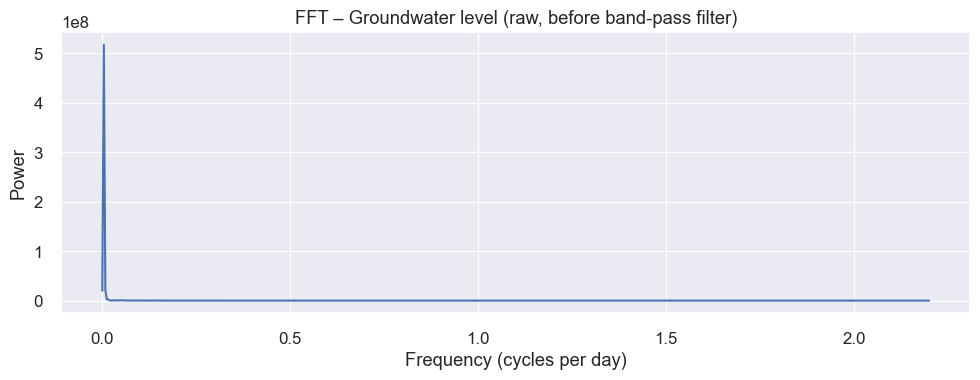

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ============================
# Configurações
# ============================
col = "gmu_gwl_mH2O"
dt_days = 0.5 / 24  # 30 minutos em dias

# limites de visualização
fmin_plot = 0.0
fmax_plot = 2.2

# ============================
# Série temporal
# ============================
series = df[col].values
n = len(series)

# ============================
# FFT (sem filtro)
# ============================
fft_vals = np.fft.fft(series)
freqs = np.fft.fftfreq(n, d=dt_days)  # ciclos por dia
power = np.abs(fft_vals) ** 2

# apenas frequências positivas
mask = (freqs >= fmin_plot) & (freqs <= fmax_plot)
freqs_plot = freqs[mask]
power_plot = power[mask]

# ============================
# Plot
# ============================
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(freqs_plot, power_plot)
ax.set_xlabel("Frequency (cycles per day)")
ax.set_ylabel("Power")
ax.set_title("FFT – Groundwater level (raw, before band-pass filter)")

ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.grid(True, which="major", axis="both", linewidth=0.8)

plt.tight_layout()
plt.show()


In [37]:
import numpy as np
import pandas as pd
from scipy.signal import csd, welch

# ======================================================
# Configurações
# ======================================================
samples_per_day = 48
fs = samples_per_day
fmin, fmax = 0.5, 2.2

edge_days = 5
edge_samples = edge_days * samples_per_day

# ======================================================
# Constantes físicas
# ======================================================
rho_w = 1000.0        # kg/m³
g = 9.81              # m/s²
K_eff = 1e9           # Pa (módulo volumétrico efetivo)
C_tide = 1e-9         # strain / (nm/s²)

# ======================================================
# Séries válidas (sem bordas)
# ======================================================
gwl = filtered_series_pd.iloc[edge_samples:-edge_samples].values

# barometria: mH2O → Pa → strain
baro_m = df["baro_ig_mH2O"].iloc[edge_samples:-edge_samples].values
baro_pa = rho_w * g * baro_m
baro_strain = baro_pa / K_eff

# maré terrestre: nm/s² → strain
tide_acc = df["earth_tide_nm/s2"].iloc[edge_samples:-edge_samples].values
tide_strain = tide_acc * C_tide

# remover média
gwl -= np.mean(gwl)
baro_strain -= np.mean(baro_strain)
tide_strain -= np.mean(tide_strain)

# ======================================================
# Função espectral (strain-based)
# ======================================================
def spectral_relationship(x, y, fs, fmin, fmax):
    f, Pxy = csd(x, y, fs=fs, nperseg=2048)
    _, Pxx = welch(x, fs=fs, nperseg=2048)
    _, Pyy = welch(y, fs=fs, nperseg=2048)

    mask = (f >= fmin) & (f <= fmax)

    coherence = np.abs(Pxy[mask])**2 / (Pxx[mask] * Pyy[mask])
    gain = np.abs(Pxy[mask]) / Pyy[mask]      # mH2O / strain
    phase = np.angle(Pxy[mask], deg=True)

    return pd.DataFrame({
        "frequency_cpd": f[mask],
        "coherence": coherence,
        "gain_mH2O_per_strain": gain,
        "phase_deg": phase
    })

# ======================================================
# Cálculos
# ======================================================
spec_baro = spectral_relationship(gwl, baro_strain, fs, fmin, fmax)
spec_tide = spectral_relationship(gwl, tide_strain, fs, fmin, fmax)

# ======================================================
# Contribuição relativa (coerência integrada)
# ======================================================
var_baro = np.trapz(spec_baro["coherence"], spec_baro["frequency_cpd"])
var_tide = np.trapz(spec_tide["coherence"], spec_tide["frequency_cpd"])

contrib_df = pd.DataFrame({
    "process": ["Barometric pressure", "Earth tide"],
    "relative_contribution": [
        var_baro / (var_baro + var_tide),
        var_tide / (var_baro + var_tide)
    ]
})

spec_baro, spec_tide, contrib_df


(    frequency_cpd  coherence  gain_mH2O_per_strain   phase_deg
 0        0.515625   0.154705         148008.288883 -159.449352
 1        0.539062   0.005037          29665.813689  -32.486980
 2        0.562500   0.079638         171319.112053    7.271860
 3        0.585938   0.031129          97459.816213   57.582759
 4        0.609375   0.027666          42128.817838  -66.839136
 ..            ...        ...                   ...         ...
 67       2.085938   0.096585          61704.459509  155.098395
 68       2.109375   0.165702          87158.730677  169.768838
 69       2.132812   0.063697          72463.530563 -114.943915
 70       2.156250   0.007640          22913.459270  -69.229739
 71       2.179688   0.092615          58472.245587   82.659438
 
 [72 rows x 4 columns],
     frequency_cpd  coherence  gain_mH2O_per_strain   phase_deg
 0        0.515625   0.012846          5.732167e+07   90.294772
 1        0.539062   0.123986          1.429896e+08 -106.555043
 2        0.56

In [38]:
# ============================
# Filtrar frequências com coerência significativa
# ============================
coherence_threshold = 0.4

baro_coherent = (
    spec_baro[spec_baro["coherence"] > coherence_threshold]
    .copy()
    .assign(process="Barometric pressure")
)

tide_coherent = (
    spec_tide[spec_tide["coherence"] > coherence_threshold]
    .copy()
    .assign(process="Earth tide")
)

# ============================
# DataFrame final consolidado
# ============================
coherent_freq_df = pd.concat(
    [baro_coherent, tide_coherent],
    ignore_index=True
).sort_values(["process", "frequency_cpd"])

coherent_freq_df


,frequency_cpd,coherence,gain_mH2O_per_strain,phase_deg,process
0,0.984375,0.760394,6.615412e+05,-20.193218,Barometric pressure
1,1.007812,0.641534,5.829012e+05,-20.901012,Barometric pressure
2,1.546875,0.427481,2.454309e+05,-156.608739,Barometric pressure
3,1.570312,0.504244,2.665757e+05,-148.827082,Barometric pressure
4,1.921875,0.429585,2.378390e+06,-158.369617,Barometric pressure
5,1.968750,0.682530,2.507793e+05,-110.728359,Barometric pressure
6,1.992188,0.900465,2.628871e+05,-126.519265,Barometric pressure
7,2.015625,0.907266,2.553251e+05,-127.803901,Barometric pressure
8,2.039062,0.604811,1.558999e+05,-142.402713,Barometric pressure
9,0.914062,0.738835,3.623450e+04,-58.062496,Earth tide


In [39]:
import numpy as np
import pandas as pd
from scipy.signal import welch

# ======================================================
# Configurações
# ======================================================
samples_per_day = 48
fs = samples_per_day
fmin, fmax = 0.5, 2.2

# ======================================================
# Função para contribuição em mH2O
# ======================================================
def gwl_contribution(spec_df, forcing_strain, fs, fmin, fmax):
    """
    Retorna a contribuição RMS do GWL (em mH2O)
    explicada por uma forçante no intervalo espectral.
    """
    # espectro da forçante
    f, Pyy = welch(forcing_strain, fs=fs, nperseg=2048)

    mask = (f >= fmin) & (f <= fmax)

    # interpolar ganho para o mesmo eixo de frequência
    gain_interp = np.interp(
        f[mask],
        spec_df["frequency_cpd"],
        spec_df["gain_mH2O_per_strain"]
    )

    # energia da resposta
    response_psd = (gain_interp ** 2) * Pyy[mask]

    # RMS da contribuição
    rms = np.sqrt(np.trapz(response_psd, f[mask]))

    return rms

# ======================================================
# Contribuições
# ======================================================
gwl_baro_mH2O = gwl_contribution(
    spec_baro,
    baro_strain,
    fs,
    fmin,
    fmax
)

gwl_tide_mH2O = gwl_contribution(
    spec_tide,
    tide_strain,
    fs,
    fmin,
    fmax
)

# ======================================================
# DataFrame final
# ======================================================
gwl_contrib_df = pd.DataFrame({
    "process": ["Barometric pressure", "Earth tide"],
    "gwl_contribution_mH2O_RMS": [
        gwl_baro_mH2O,
        gwl_tide_mH2O
    ]
})

# porcentagem relativa
total = gwl_contrib_df["gwl_contribution_mH2O_RMS"].sum()
gwl_contrib_df["relative_fraction"] = (
    gwl_contrib_df["gwl_contribution_mH2O_RMS"] / total
)

gwl_contrib_df


,process,gwl_contribution_mH2O_RMS,relative_fraction
0,Barometric pressure,0.041025,0.530955
1,Earth tide,0.036241,0.469045


In [42]:
import numpy as np
import pandas as pd
from scipy.signal import welch

# ======================================================
# Configurações
# ======================================================
samples_per_day = 48
fs = samples_per_day

# Bandas físicas (cpd) baseadas na tabela
bands = {
    "Q1–O1–M1 (diurnal tide)": (0.88, 0.97),
    "P1–S1–K1 (diurnal atm+tide)": (0.98, 1.02),
    "N2–M2 (semidiurnal tide)": (1.88, 1.95),
    "S2–K2 (semidiurnal atm+tide)": (1.98, 2.02),
}

# ======================================================
# Função: contribuição RMS por banda
# ======================================================
def gwl_contribution_band(spec_df, forcing_strain, fs, band):
    f, Pyy = welch(forcing_strain, fs=fs, nperseg=2048)

    band_mask = (f >= band[0]) & (f <= band[1])

    gain_interp = np.interp(
        f[band_mask],
        spec_df["frequency_cpd"],
        spec_df["gain_mH2O_per_strain"]
    )

    response_psd = (gain_interp ** 2) * Pyy[band_mask]

    rms_m = np.sqrt(np.trapz(response_psd, f[band_mask]))

    return rms_m * 100  # cm RMS

# ======================================================
# Cálculo por banda
# ======================================================
rows = []

for band_name, band_range in bands.items():
    baro_cm = gwl_contribution_band(
        spec_baro, baro_strain, fs, band_range
    )
    tide_cm = gwl_contribution_band(
        spec_tide, tide_strain, fs, band_range
    )

    total = baro_cm + tide_cm

    rows.append({
        "band": band_name,
        "barometric_cm_RMS": baro_cm,
        "earth_tide_cm_RMS": tide_cm,
        "total_cm_RMS": total,
        "baro_fraction": baro_cm / total if total > 0 else np.nan,
        "tide_fraction": tide_cm / total if total > 0 else np.nan,
    })

band_contrib_df = pd.DataFrame(rows)

band_contrib_df


,band,barometric_cm_RMS,earth_tide_cm_RMS,total_cm_RMS,baro_fraction,tide_fraction
0,Q1–O1–M1 (diurnal tide),0.185713,0.779144,0.964857,0.192477,0.807523
1,P1–S1–K1 (diurnal atm+tide),2.277821,1.110904,3.388725,0.672176,0.327824
2,N2–M2 (semidiurnal tide),1.213635,2.003000,3.216635,0.377300,0.622700
3,S2–K2 (semidiurnal atm+tide),1.366939,1.410789,2.777728,0.492107,0.507893
